# Detekcja satelitów w FFS — krok po kroku

Notatnik do pracy nad detekcją linii w `pyaraucaria/ffs.py` (`mk_stats()` → `self.maska`,
`hough_transform()`, `find_lines()`). Pokazuje, co dzieje się na każdym etapie, na klatce
syntetycznej ze znaną prawdą (i na końcu na prawdziwej jk15c).

**Sposób pracy:** zmieniasz `ffs.py`, uruchamiasz ponownie komórki (Run All) — dzięki
`%autoreload` zmiany są wczytywane bez restartu jądra. Liczby do obserwowania zbiera
komórka „Diagnostyka” w sekcji 5.

| # | krok | w `ffs.py` |
|---|---|---|
| 1 | przygotowanie obrazu (tło, binowanie) | brak (jest `sky_gradient`, nieużywany tutaj) |
| 2 | piksele kandydatów → wejście Hougha | `mk_stats()` → `self.maska`; `line_filter()` niepodłączony |
| 3 | transformata Hougha | `hough_transform()` — siatka θ bez dublowania ±90°, z 0°; siatka ρ zgodna z regułą `ri` |
| 4 | wybór linii | pętla: komórka z największą liczbą głosów → wypełnienie (głosy / długość linii w klatce) → przyjęcie i usunięcie jej pikseli albo odrzucenie |
| 5–9 | weryfikacja (dokładniejsza), pomiar, klasyfikacja, maska | brak |

Konwencje: `image[y, x]`; linia `x·cos θ + y·sin θ = ρ`, θ — kierunek normalnej do linii.

In [1]:
%load_ext autoreload
%autoreload 2

import inspect
import os
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize, ZScaleInterval, LogStretch

REPO = os.path.abspath("..")
if REPO not in sys.path:
    sys.path.insert(0, REPO)

from pyaraucaria.ffs import FFS
from tests import ffs_synth

warnings.simplefilter("ignore", RuntimeWarning)
%matplotlib inline
%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight", "pil_kwargs": {"quality": 85}}
plt.rcParams["figure.dpi"] = 100


def show(img, ax=None, title=None, extent=None):
    ax = ax or plt.gca()
    norm = ImageNormalize(img, interval=ZScaleInterval())
    ax.imshow(img, origin="lower", cmap="gray", norm=norm, interpolation="nearest", extent=extent)
    ax.set_xlabel("x [px]"); ax.set_ylabel("y [px]")
    if title:
        ax.set_title(title)
    return ax


def line_params(x0, y0, x1, y1):
    # (theta, rho) of the line through two points, theta folded into [-90, 90) deg
    n = np.array([-(y1 - y0), x1 - x0]) / np.hypot(x1 - x0, y1 - y0)
    theta, rho = np.arctan2(n[1], n[0]), x0 * n[0] + y0 * n[1]
    if theta >= np.pi / 2:
        theta, rho = theta - np.pi, -rho
    elif theta < -np.pi / 2:
        theta, rho = theta + np.pi, -rho
    return theta, rho


def line_xy(rho, theta, length=5000):
    # two far-apart points of the line, for plotting
    c, s = np.cos(theta), np.sin(theta)
    x0, y0 = rho * c, rho * s
    return np.array([x0 - length * s, x0 + length * s]), np.array([y0 + length * c, y0 - length * c])


def same_line(rho, theta, rho_t, theta_t):
    # (theta, rho) and (theta -+ pi, -rho) are the same line; return errors vs truth
    if abs(theta - theta_t) > np.pi / 2:
        theta, rho = theta - np.pi * np.sign(theta - theta_t), -rho
    return rho - rho_t, np.rad2deg(theta - theta_t)

## Klatka testowa

`scenario("typical")` z `tests/ffs_synth.py`: 512×512, tło 1000 ADU z gradientem,
42 gwiazdy (dwie nasycone z przelewem), 3 gorące piksele, zła kolumna x = 260 (+400 ADU)
i **jeden ślad satelity** od (0, 60) do (511, 300), FWHM 2,5 px, 300 ADU w szczycie
(~9σ na piksel).

prawda: theta = -64.84 deg, rho = -54.31 px


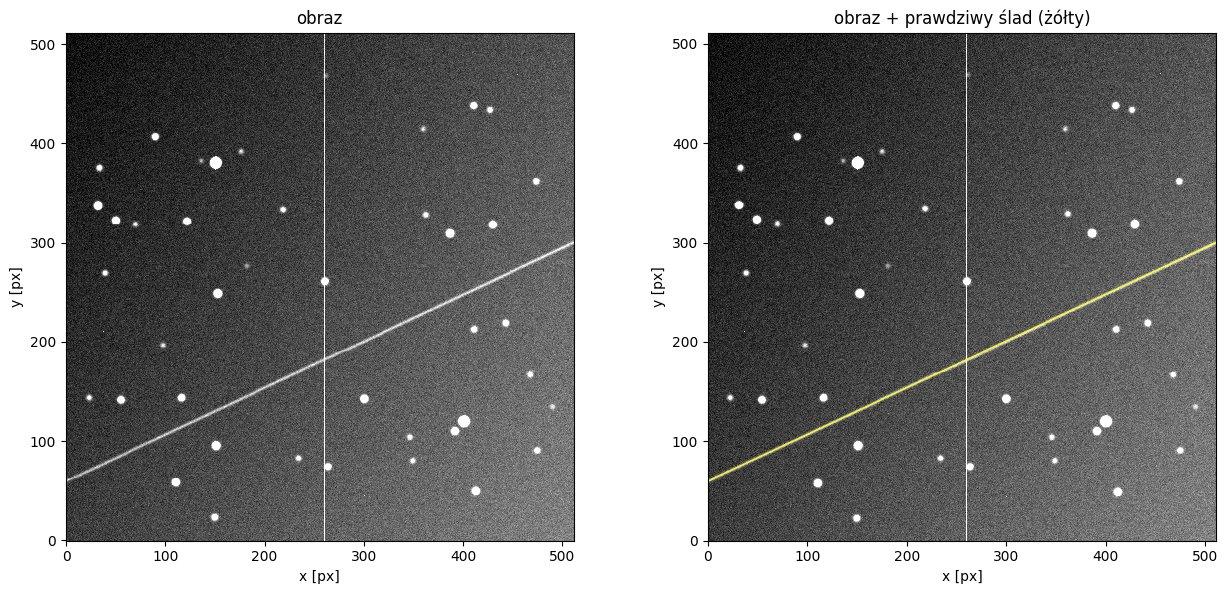

In [2]:
frame = ffs_synth.scenario("typical")
image = frame.image
trail = frame.truth["lines"][0]
theta_t, rho_t = line_params(trail["x0"], trail["y0"], trail["x1"], trail["y1"])
print(f"prawda: theta = {np.rad2deg(theta_t):.2f} deg, rho = {rho_t:.2f} px")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
show(image, axes[0], "obraz")
show(image, axes[1], "obraz + prawdziwy ślad (żółty)")
axes[1].plot(*line_xy(rho_t, theta_t), color="yellow", lw=0.8)
axes[1].set_xlim(0, 511); axes[1].set_ylim(0, 511)
plt.tight_layout()

## Krok 2 — piksele kandydatów: `mk_stats()` → `self.maska`

`self.maska = image > median(image) + 3·q_sigma` — próg globalny na surowym obrazie.
Każdy piksel maski głosuje w Houghu z wagą 1. Obok, dla porównania, wynik `line_filter()`
(filtr pierścieniowy) — obecnie nie jest podłączony do Hougha.

median = 1001.4, q_sigma = 66.45, próg = 1200.7
pikseli w masce: 3512 (1.34% klatki; sam szum dałby ~0.13%)


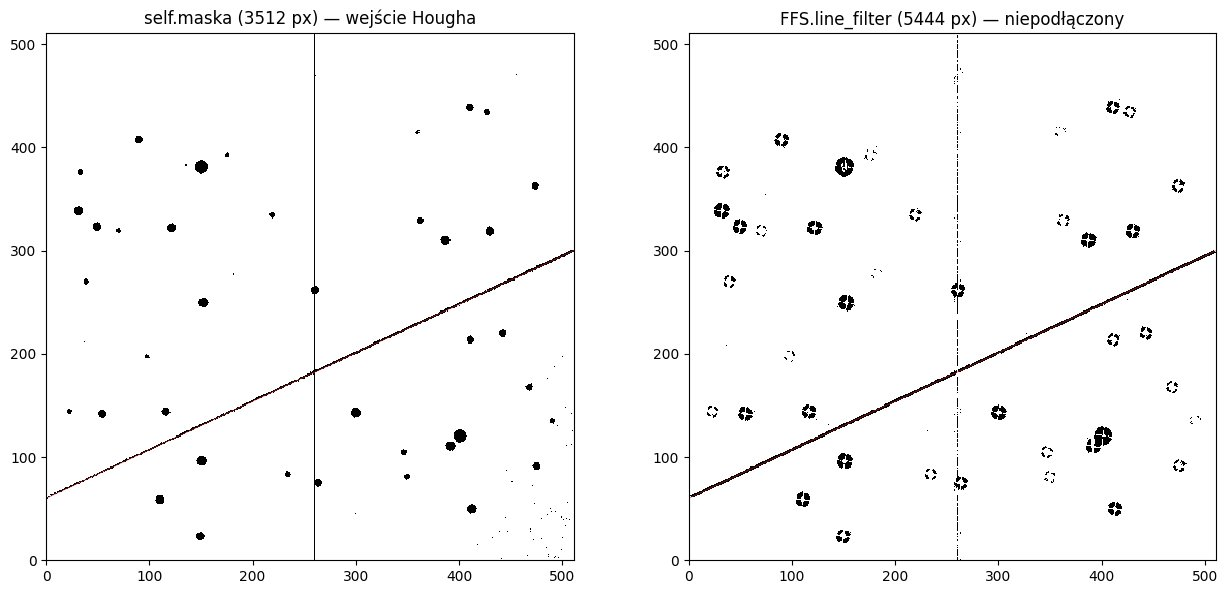

In [3]:
ffs = FFS(image)
ffs.mk_stats()
print(f"median = {ffs.median:.1f}, q_sigma = {ffs.q_sigma:.2f}, próg = {ffs.median + 3 * ffs.q_sigma:.1f}")
print(f"pikseli w masce: {ffs.maska.sum()} ({100 * ffs.maska.mean():.2f}% klatki; "
      f"sam szum dałby ~0.13%)")

lf = FFS.line_filter(image.astype(float))
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(ffs.maska, origin="lower", cmap="gray_r", interpolation="nearest")
axes[0].set_title(f"self.maska ({ffs.maska.sum()} px) — wejście Hougha")
axes[1].imshow(lf, origin="lower", cmap="gray_r", interpolation="nearest")
axes[1].set_title(f"FFS.line_filter ({lf.sum()} px) — niepodłączony")
for ax in axes:
    ax.plot(*line_xy(rho_t, theta_t), color="tab:red", lw=0.6, alpha=0.6)
    ax.set_xlim(0, 511); ax.set_ylim(0, 511)
plt.tight_layout()

## Krok 3 — transformata Hougha: `hough_transform()`

Każdy piksel maski (x, y) głosuje na wszystkie linie, które przez niego przechodzą:
dla każdego θ z siatki liczone jest ρ = x·cos θ + y·sin θ i wrzucane do koszyka.
Wynik: `self.accumulator` (koszyki ρ × kąty θ), `self.rh` (wartości ρ koszyków),
`self.hough_theta`. Ślad to jeden jasny punkt; gwiazda — sinusoida.

accumulator: (1449, 180) (koszyki rho × kąty), rh od -724.00 do 724.00
kąty: od -90.000 do 89.000 deg, co 1.000 deg


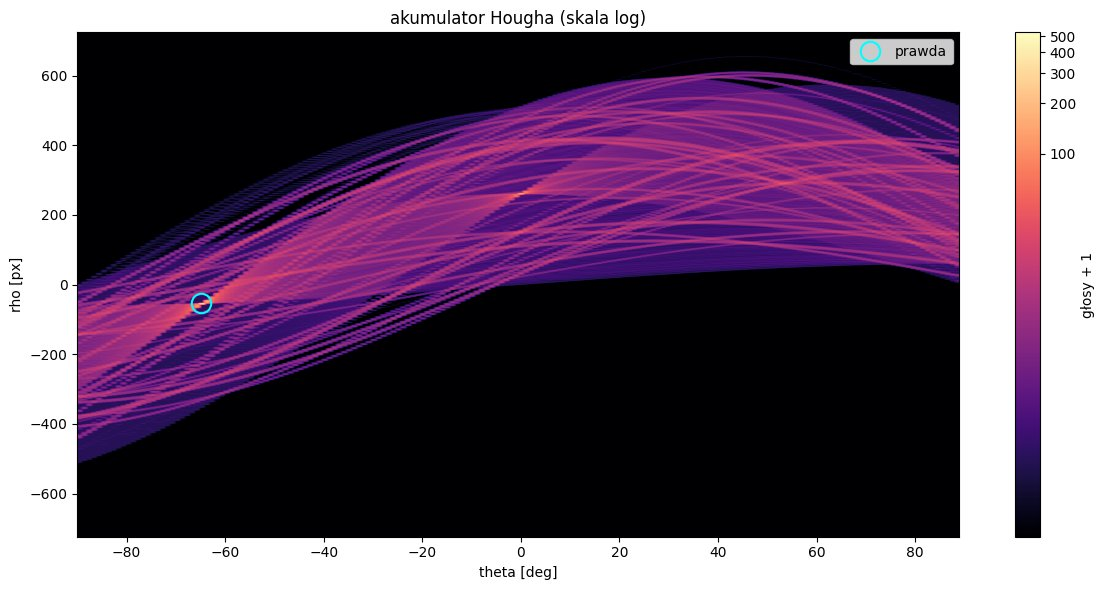

In [4]:
ffs.hough_transform()
acc = ffs.accumulator
th_deg = np.rad2deg(ffs.hough_theta)
print(f"accumulator: {acc.shape} (koszyki rho × kąty), rh od {ffs.rh[0]:.2f} do {ffs.rh[-1]:.2f}")
print(f"kąty: od {th_deg[0]:.3f} do {th_deg[-1]:.3f} deg, co {th_deg[1] - th_deg[0]:.3f} deg")

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(acc + 1, origin="lower", aspect="auto", cmap="magma",
               norm=ImageNormalize(acc + 1, stretch=LogStretch()),
               extent=(th_deg[0], th_deg[-1], ffs.rh[0], ffs.rh[-1]))
ax.plot(np.rad2deg(theta_t), rho_t, "o", mfc="none", mec="cyan", ms=14, mew=1.5, label="prawda")
ax.set_xlabel("theta [deg]"); ax.set_ylabel("rho [px]")
ax.set_title("akumulator Hougha (skala log)")
ax.legend(); plt.colorbar(im, ax=ax, label="głosy + 1")
plt.tight_layout()

Zbliżenie na okolicę prawdy, w **indeksach** koszyków. Krzyżyk — gdzie prawda powinna
trafić wg reguły z linii `ri = round(rho + rh0)` (koszyk k ↔ ρ = k − rh0).

najwięcej głosów w koszyku 669: rh[669] = -55.00, a reguła ri daje rho = -55; prawda -54.31


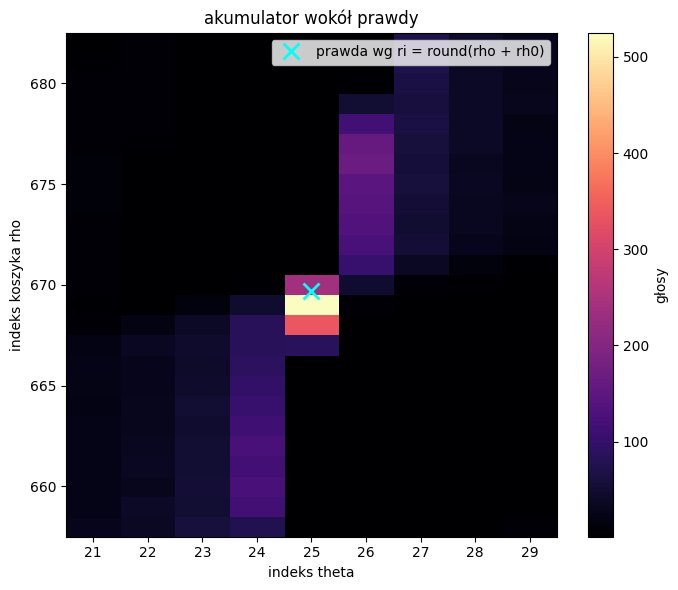

In [5]:
k_t = int(np.argmin(np.abs(ffs.rh - rho_t)))           # bin whose rh value is closest to the truth
t_t = int(np.argmin(np.abs(ffs.hough_theta - theta_t)))
rh0 = (len(ffs.rh)) // 2                                  # as in hough_transform: len(rh) = 2*rh0
k_rule = rho_t + rh0                                      # where line 702 puts the true rho
dk, dt = 12, 4
sub = acc[k_t - dk:k_t + dk + 1, t_t - dt:t_t + dt + 1]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sub, origin="lower", aspect="auto", cmap="magma", interpolation="nearest",
               extent=(t_t - dt - 0.5, t_t + dt + 0.5, k_t - dk - 0.5, k_t + dk + 0.5))
ax.plot(t_t, k_rule, "x", color="cyan", ms=12, mew=2, label="prawda wg ri = round(rho + rh0)")
ax.set_xlabel("indeks theta"); ax.set_ylabel("indeks koszyka rho")
ax.set_title("akumulator wokół prawdy"); ax.legend(loc="upper right")
plt.colorbar(im, ax=ax, label="głosy")
plt.tight_layout()
k_max = np.unravel_index(np.argmax(sub), sub.shape)[0] + k_t - dk
print(f"najwięcej głosów w koszyku {k_max}: rh[{k_max}] = {ffs.rh[k_max]:.2f}, "
      f"a reguła ri daje rho = {k_max - rh0}; prawda {rho_t:.2f}")

### Siatka ρ: co znaczy koszyk?

Dwie linie `hough_transform()` opisują koszyki ρ:

```python
rh = np.arange(-rh0, rh0 + 1, dtype=float)    # wartość rho przypisana koszykowi k
ri = np.round(rho_mtx + rh0).astype(int)      # do którego koszyka trafia głos
```

Wykres pokazuje różnicę `rh[k] − (k − rh0)`: wartość, którą odczytujemy z koszyka, minus
ρ głosów, które do niego naprawdę trafiły — po poprawce 0 wszędzie (wcześniej, z
`linspace`, rosła do 1 px). Druga część komórki sprawdza, czy największy możliwy indeks
`ri` mieści się w akumulatorze.

rh0 = 724, koszyków: 1449 (indeksy 0..1448)
zakres indeksów ri dla narożników klatki: 213 .. 1447


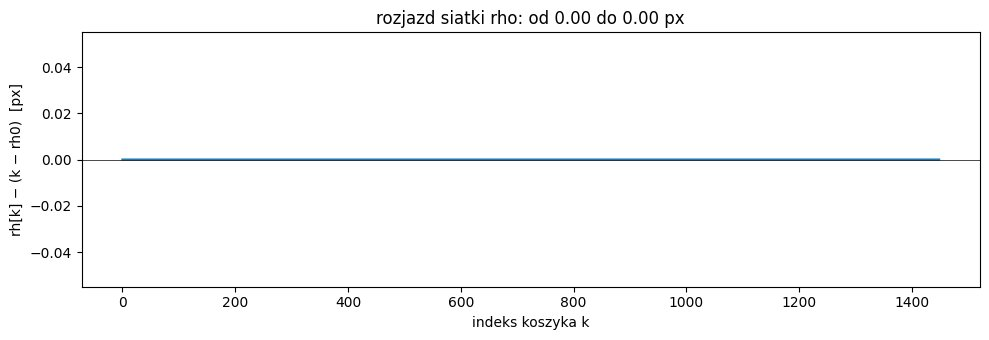

In [6]:
k = np.arange(len(ffs.rh))
diff = ffs.rh - (k - rh0)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(k, diff)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("indeks koszyka k"); ax.set_ylabel("rh[k] − (k − rh0)  [px]")
ax.set_title(f"rozjazd siatki rho: od {diff.min():.2f} do {diff.max():.2f} px")
plt.tight_layout()

ny, nx = image.shape
corners = [(0, 0), (nx - 1, 0), (0, ny - 1), (nx - 1, ny - 1)]
th = ffs.hough_theta
ri_all = [np.round(x * np.cos(th) + y * np.sin(th) + rh0).astype(int) for x, y in corners]
print(f"rh0 = {rh0}, koszyków: {acc.shape[0]} (indeksy 0..{acc.shape[0] - 1})")
print(f"zakres indeksów ri dla narożników klatki: {min(r.min() for r in ri_all)} .. {max(r.max() for r in ri_all)}")

## Krok 4 — wybór linii: pętla w `hough_transform()`

W każdym obrocie pętli (najwyżej `max_candidates`):

1. komórka z największą liczbą głosów; jeśli głosów < `min_length` — koniec,
2. **wypełnienie** = głosy / długość linii w klatce (`_full_line_length`) — jaka część
   pikseli tej linii jest w masce; jeśli < `line_threshold` — kandydat odrzucony: komórka
   i jej sąsiedzi (±2 ρ, ±1 θ) są wyłączani, piksele zostają,
3. przyjęta linia: zapis i usunięcie głosów pikseli maski w odległości ≤ `half_width`
   (z nimi znika cały „motyl” wokół linii).

Wykres: każda komórka akumulatora z co najmniej `min_length` głosami — głosy vs
wypełnienie. Czerwone — komórki przy przyjętych liniach. To wypełnienie *pierwotnego*
akumulatora (przed odejmowaniem głosów w pętli). Przy kątach bliskich 45° wypełnienie
idealnej linii skacze między ~0.7 a ~1.4 (siatka pikseli), więc to nie jest dokładny procent.

hough_transform: min_length = 30, line_threshold = 0.5, half_width = 3.0


 val     rho    theta[deg]  długość  wypełnienie | d_rho  d_theta[deg]  (względem śladu)
  525   -55.00    -65.00       565        0.93  |  -0.69    -0.16
  505   260.00      0.00       512        0.99  |   inny obiekt (zła kolumna x = 260)


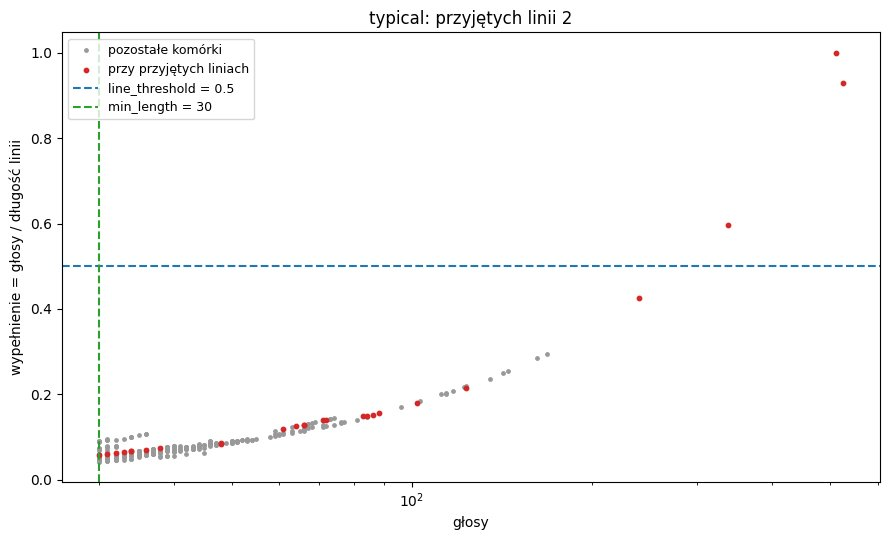

In [7]:
params = inspect.signature(FFS.hough_transform).parameters
MIN_LENGTH = params["min_length"].default
LINE_THRESHOLD = params["line_threshold"].default
print(f"hough_transform: min_length = {MIN_LENGTH}, line_threshold = {LINE_THRESHOLD}, "
      f"half_width = {params['half_width'].default}")


def fill_of_cells(f, max_cells=20000):
    # votes and fill (votes / line length in the frame) of the strongest accumulator cells
    acc = f.accumulator
    ri, ti = np.nonzero(acc >= MIN_LENGTH)
    order = np.argsort(acc[ri, ti])[::-1][:max_cells]
    ri, ti = ri[order], ti[order]
    votes = acc[ri, ti]
    length = np.array([FFS._full_line_length(f.rh[r], f.hough_theta[t], f.image.shape) for r, t in zip(ri, ti)])
    near = np.zeros(len(ri), dtype=bool)
    for rho, th in zip(f.lines_rho, f.lines_theta):
        near |= (np.abs(f.rh[ri] - rho) <= 3) & (np.abs(f.hough_theta[ti] - th) <= np.deg2rad(2))
    return votes, votes / np.maximum(length, 1), length, near


def plot_fill(f, ax, title):
    votes, fill, length, near = fill_of_cells(f)
    ax.scatter(votes[~near], fill[~near], s=6, color="0.6", label="pozostałe komórki")
    ax.scatter(votes[near], fill[near], s=10, color="tab:red", label="przy przyjętych liniach")
    ax.axhline(LINE_THRESHOLD, color="tab:blue", ls="--", label=f"line_threshold = {LINE_THRESHOLD}")
    ax.axvline(MIN_LENGTH, color="tab:green", ls="--", label=f"min_length = {MIN_LENGTH}")
    ax.set_xscale("log")
    ax.set_xlabel("głosy"); ax.set_ylabel("wypełnienie = głosy / długość linii")
    ax.set_title(title); ax.legend(loc="upper left", fontsize=9)


fig, ax = plt.subplots(figsize=(9, 5.5))
plot_fill(ffs, ax, f"typical: przyjętych linii {len(ffs.lines_val)}")
plt.tight_layout()

print(" val     rho    theta[deg]  długość  wypełnienie | d_rho  d_theta[deg]  (względem śladu)")
for v, r, t in zip(ffs.lines_val, ffs.lines_rho, ffs.lines_theta):
    L = FFS._full_line_length(r, t, image.shape)
    dr, dth = same_line(r, t, rho_t, theta_t)
    note = f"{dr:6.2f} {dth:8.2f}" if abs(dth) < 5 and abs(dr) < 20 else "  inny obiekt (zła kolumna x = 260)"
    print(f"{v:5.0f} {r:8.2f} {np.rad2deg(t):9.2f}  {L:8.0f}  {v / L:10.2f}  | {note}")

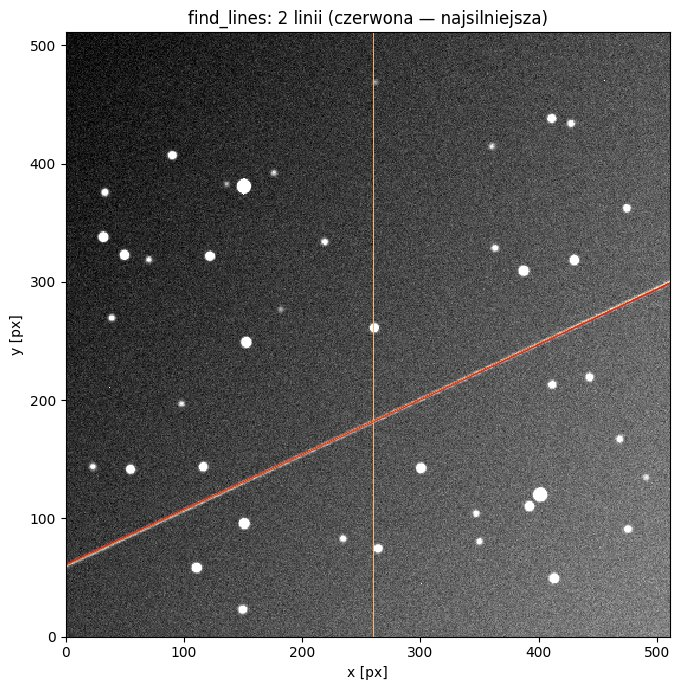

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
show(image, ax, f"find_lines: {len(ffs.lines_val)} linii (czerwona — najsilniejsza)")
for i, (r, t) in enumerate(zip(ffs.lines_rho, ffs.lines_theta)):
    ax.plot(*line_xy(r, t), color="tab:red" if i == 0 else "tab:orange",
            lw=1.5 if i == 0 else 0.6, alpha=1 if i == 0 else 0.7)
ax.plot(*line_xy(rho_t, theta_t), color="yellow", lw=0.6, ls=":")
ax.set_xlim(0, 511); ax.set_ylim(0, 511)
plt.tight_layout()

## 5. Diagnostyka — liczby do obserwowania po każdej zmianie

Uruchamia `find_lines()` od nowa na tej samej klatce i testy `TestLines`
z `tests/test_ffs_truth.py` (ślad wykryty dokładnie raz, linia przechodzi < 0.5 px od
środka śladu).

In [9]:
import unittest

f = FFS(image); f.mk_stats(); f.find_lines()
dr, dth = same_line(f.lines_rho[0], f.lines_theta[0], rho_t, theta_t)
xm, ym = (trail["x0"] + trail["x1"]) / 2, (trail["y0"] + trail["y1"]) / 2
offset = abs(xm * np.cos(f.lines_theta[0]) + ym * np.sin(f.lines_theta[0]) - f.lines_rho[0])
print(f"liczba linii:                       {len(f.lines_val)}   (cel: 2 — ślad i zła kolumna)")
print(f"najsilniejsza: odległość od śladu = {offset:.2f} px (cel: < 0.5)")
print(f"               błąd theta         = {dth:+.2f} deg (siatka co 1 deg)")
print()
suite = unittest.defaultTestLoader.loadTestsFromName("tests.test_ffs_truth.TestLines")
unittest.TextTestRunner(verbosity=2, stream=sys.stdout).run(suite);

liczba linii:                       2   (cel: 2 — ślad i zła kolumna)
najsilniejsza: odległość od śladu = 0.16 px (cel: < 0.5)
               błąd theta         = -0.16 deg (siatka co 1 deg)

test_single_trail_single_line (tests.test_ffs_truth.TestLines.test_single_trail_single_line) ... 

ok


test_strongest_line_orientation (tests.test_ffs_truth.TestLines.test_strongest_line_orientation) ... 

ok


test_strongest_line_through_trail_centre (tests.test_ffs_truth.TestLines.test_strongest_line_through_trail_centre) ... 

ok


----------------------------------------------------------------------
Ran 3 tests in 0.381s

OK


## 6. Prawdziwa klatka jk15c

Ta sama ścieżka na klatce z OCA (bez satelitów — cel: 0 linii). Wykres jak w kroku 4:
najsilniejsze komórki akumulatora mają dużo głosów (gęsta maska przy krawędziach,
długie linie), ale małe wypełnienie, więc są odrzucane.

jk15c: pikseli w masce 116458 (0.69%), linii: 0


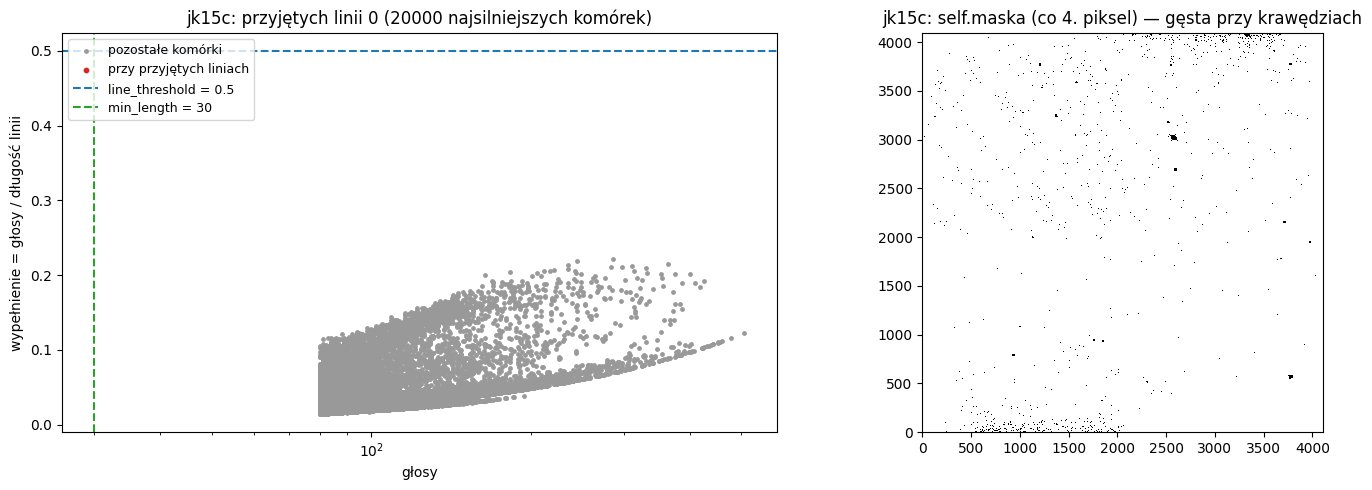

In [10]:
from astropy.io import fits

FITS_PATH = os.path.expanduser("~/work/data/fits_examples/jk15c_0154_73367.fits")
if os.path.exists(FITS_PATH):
    real = fits.getdata(FITS_PATH)
    fr = FFS(real); fr.mk_stats(); fr.find_lines()
    print(f"jk15c: pikseli w masce {fr.maska.sum()} ({100 * fr.maska.mean():.2f}%), linii: {len(fr.lines_val)}")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    plot_fill(fr, axes[0], f"jk15c: przyjętych linii {len(fr.lines_val)} (20000 najsilniejszych komórek)")
    axes[1].imshow(fr.maska[::4, ::4], origin="lower", cmap="gray_r", interpolation="nearest",
                   extent=(0, real.shape[1], 0, real.shape[0]))
    axes[1].set_title("jk15c: self.maska (co 4. piksel) — gęsta przy krawędziach")
    plt.tight_layout()
else:
    print("brak pliku", FITS_PATH)

## 7. Odniesienie: `satellites.find_satellites()`

Wynik wersji referencyjnej (`pyaraucaria/satellites.py`) na tej samej klatce — tylko do
porównania, nie jest częścią pracy w `ffs.py`.

In [11]:
from pyaraucaria.satellites import find_satellites

ref, ref_mask = find_satellites(image)
t = ref["x0", "y0", "x1", "y1", "rho", "theta", "width", "peak", "kind"]
t["theta"] = np.rad2deg(t["theta"])
for c in t.colnames[:-1]:
    t[c].format = ".2f"
t

x0,y0,x1,y1,rho,theta,width,peak,kind
float64,float64,float64,float64,float64,float64,float64,float64,str9
-0.50,59.77,511.50,300.23,-54.31,-64.84,2.61,292.38,satellite
260.18,-0.50,260.01,511.50,260.18,0.02,1.00,401.58,column
